In [2]:
import pandas as pd
df = pd.read_csv("Ride Apps Data Collection (Responses) - Form responses 2 (3).csv")
df.head()

,Timestamp,Your Name,Pickup Coordinate,Drop Coordinate,Fare for Bike,"[Waiting Time of Bike, No. of bikes available]",Fare for Auto,"[Waiting Time of Auto, No. of Auto Available]",Fare for Car,"[Waiting Time of Car, No. of cars available]",...,DropZone,BikeWait,BikeSupply,AutoWait,AutoSupply,CarWait,CarSupply,priceKmBike,priceKmAuto,priceKmCar
0,05/03/2026 15:08:06,Prince,"28.5391198, 77.4085046","28.5714706, 77.3819343",75.0,2,103.0,2,158.0,3,...,HEALTHCARE,2,0,2,0,3,0,8.49,11.66,17.89
1,05/03/2026 15:35:18,Prince,"28.6512698, 77.4282989","28.5714706, 77.3819343",121.0,5,224.0,5,227.0,5,...,HEALTHCARE,5,0,5,0,5,0,8.10,14.99,15.19
2,05/03/2026 15:48:43,Prince,"28.6422441, 77.2204727","28.5714706, 77.3819343",209.0,4,352.0,4,505.0,4,...,HEALTHCARE,4,0,4,0,4,0,7.46,12.56,18.03
3,05/03/2026 16:30:06,Prakhar Gupta,"28.458098, 77.508537","28.452592, 77.526631",41.0,3,55.0,4,106.0,3,...,RESIDENTIAL,3,0,4,0,3,0,10.52,14.12,27.21
4,05/03/2026 16:36:59,Prakhar Gupta,"28.4529608, 77.4996568","28.648360, 77.315601",237.0,3,396.0,7,510.0,4,...,TRANSIT_HUB,3,0,7,0,4,0,6.70,11.19,14.41


In [3]:
df.columns

Index(['Timestamp', 'Your Name', 'Pickup Coordinate', 'Drop Coordinate',
       'Fare for Bike', '[Waiting Time of Bike, No. of bikes available]',
       'Fare for Auto', '[Waiting Time of Auto, No. of Auto Available]',
       'Fare for Car', '[Waiting Time of Car, No. of cars available]',
       'Platform', '  Is a Surge/High-Demand alert visible?  ', 'Hour',
       'Minute', 'DecimalHour', 'Day', 'Weekend', 'Rushhour', 'DistanceKm',
       'Duration', 'TrafficLevel', 'SurgeValue', 'PickupTemperature',
       'PickupWindSpeed', 'PickupWeatherCode', 'PickupHumidity',
       'DropTemperature', 'DropWindSpeed', 'DropWeatherCode', 'DropHumidity',
       'PickupZone', 'DropZone', 'BikeWait', 'BikeSupply', 'AutoWait',
       'AutoSupply', 'CarWait', 'CarSupply', 'priceKmBike', 'priceKmAuto',
       'priceKmCar'],
      dtype='object')

C:\Users\princ\AppData\Local\Temp\ipykernel_7656\205591223.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


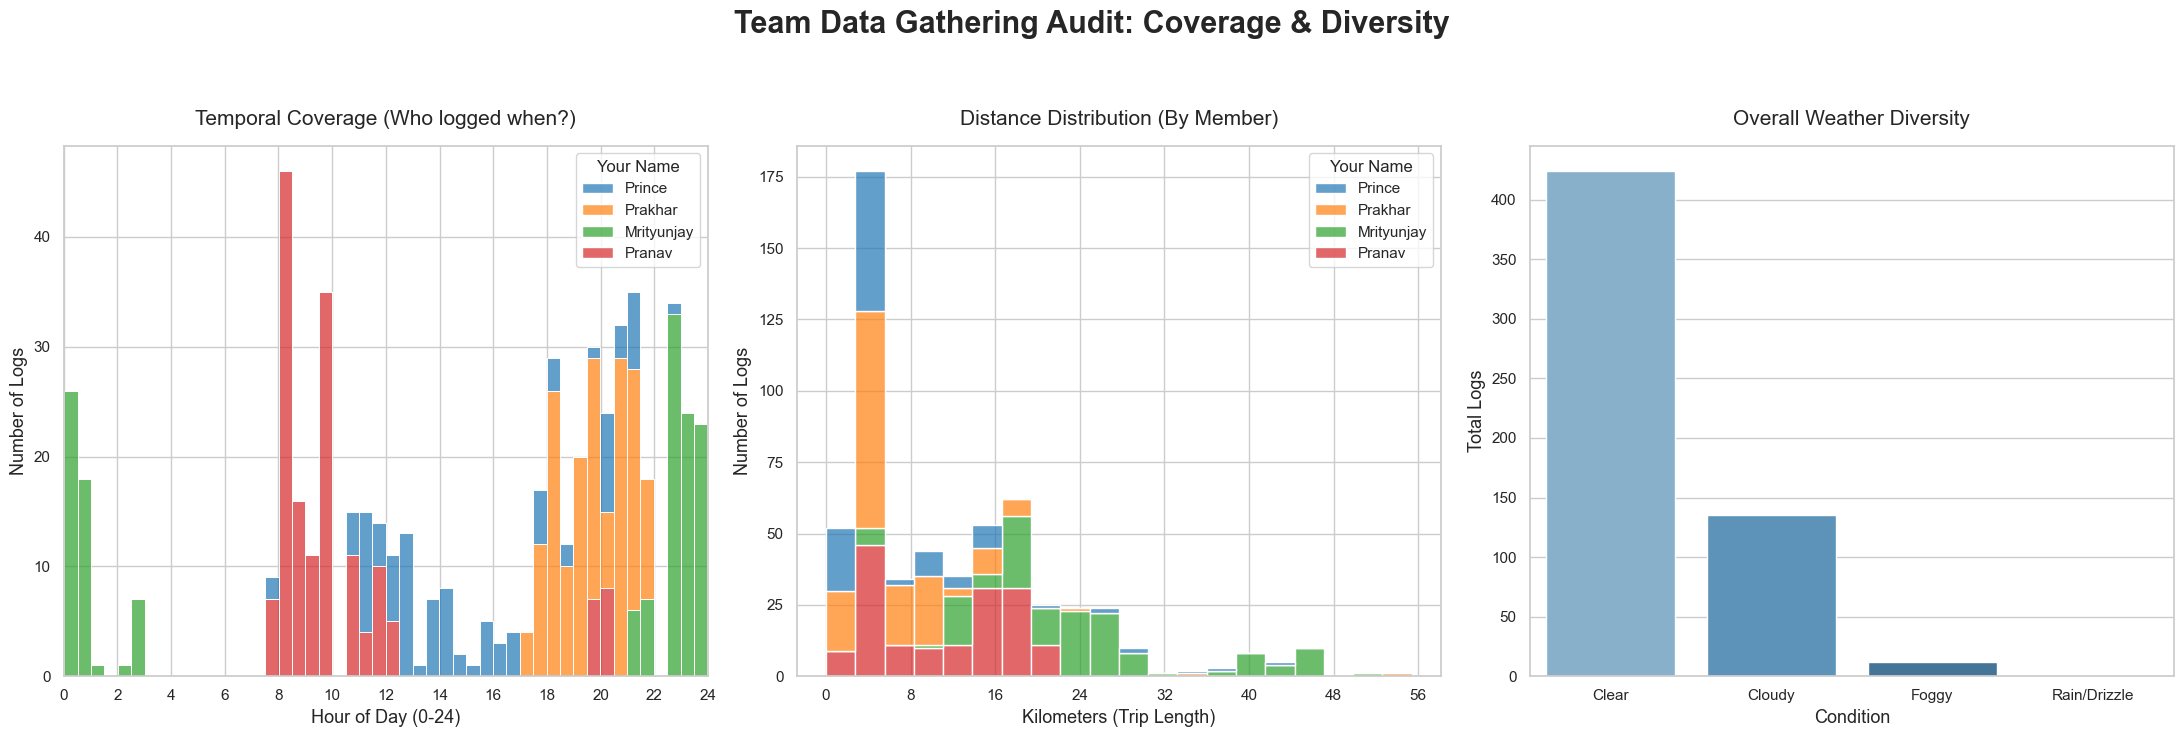

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
filename = 'Ride Apps Data Collection (Responses) - Form responses 2 (3).csv'
df = pd.read_csv(filename)

# Mapping Weather Codes
def map_weather(code):
    if pd.isna(code): return 'Unknown'
    if code == 0: return 'Clear'
    if code in [1, 2, 3]: return 'Cloudy'
    if code in [45, 48]: return 'Foggy'
    if code >= 51: return 'Rain/Drizzle'
    return 'Other'

df['Weather_Label'] = df['PickupWeatherCode'].apply(map_weather)
weather_order = ['Clear', 'Cloudy', 'Foggy', 'Rain/Drizzle']

# 1. Setup figure
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Team Data Gathering Audit: Coverage & Diversity', fontsize=22, fontweight='bold', y=1.05)

# --- PLOT 1: 24-HOUR TEMPORAL SPREAD (BY TEAM MEMBER) ---
sns.histplot(
    data=df, x='DecimalHour', hue='Your Name', 
    bins=48, multiple='stack', palette='tab10', ax=axes[0], alpha=0.7
)
axes[0].set_title('Temporal Coverage (Who logged when?)', fontsize=15, pad=15)
axes[0].set_xlabel('Hour of Day (0-24)', fontsize=13)
axes[0].set_ylabel('Number of Logs', fontsize=13)
axes[0].set_xticks(np.arange(0, 25, 2))
axes[0].set_xlim(0, 24)

# --- PLOT 2: DISTANCE CAPTURE SPREAD (BY TEAM MEMBER) ---
sns.histplot(
    data=df, x='DistanceKm', hue='Your Name', 
    bins=20, multiple='stack', palette='tab10', ax=axes[1], alpha=0.7
)
axes[1].set_title('Distance Distribution (By Member)', fontsize=15, pad=15)
axes[1].set_xlabel('Kilometers (Trip Length)', fontsize=13)
axes[1].set_ylabel('Number of Logs', fontsize=13)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(10))

# --- PLOT 3: WEATHER DIVERSITY ---
sns.countplot(
    data=df, x='Weather_Label', order=weather_order, 
    ax=axes[2], palette='Blues_d'
)
axes[2].set_title('Overall Weather Diversity', fontsize=15, pad=15)
axes[2].set_xlabel('Condition', fontsize=13)
axes[2].set_ylabel('Total Logs', fontsize=13)

plt.tight_layout()
plt.show()

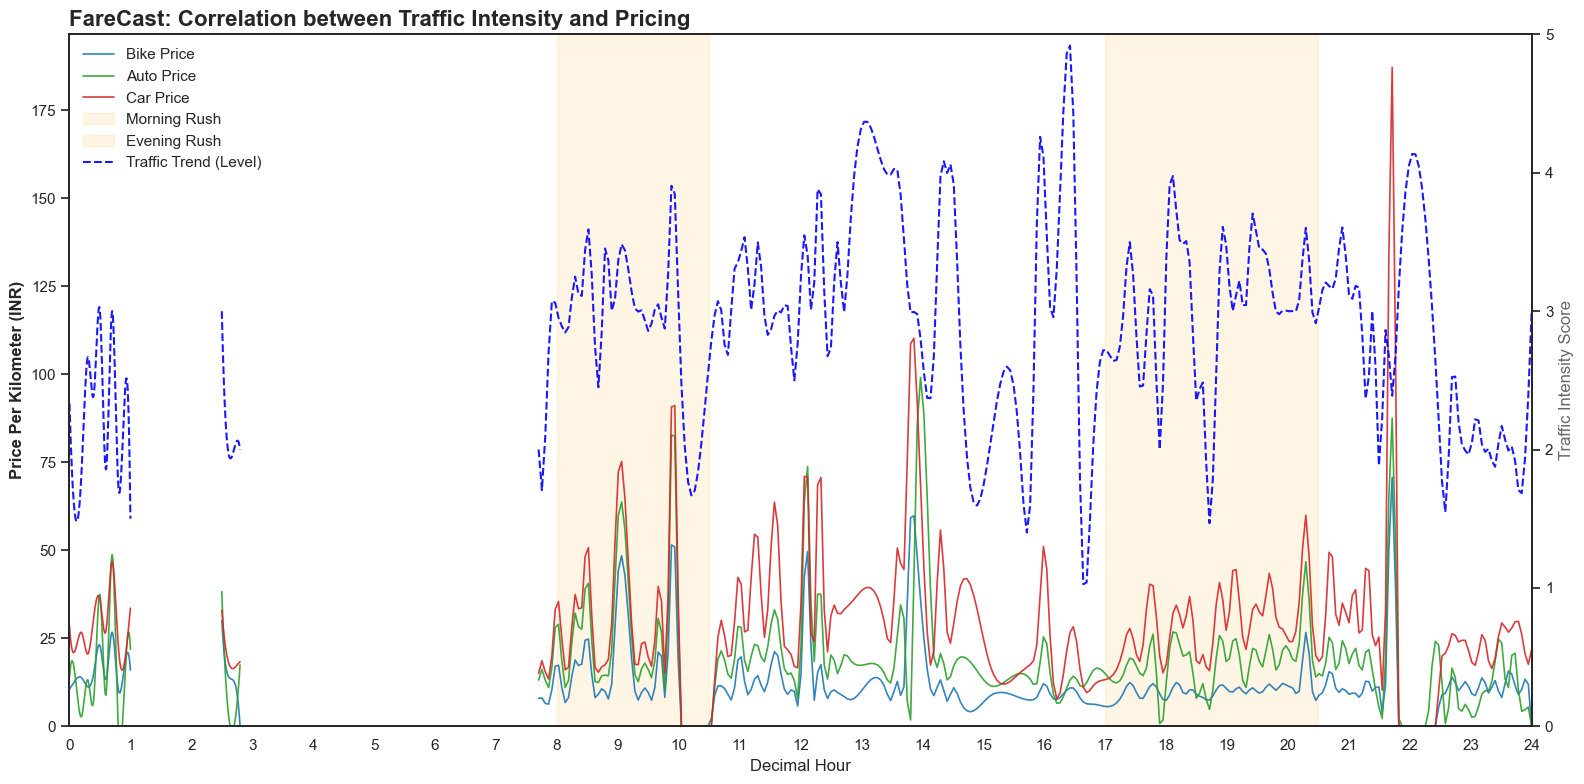

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

# 1. Load data
df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

# 2. Aggregation (Including Traffic Level)
# Mapping TrafficLevel to numeric if it's text (e.g., LOW=1, HEAVY=4)
traffic_map = {'LOW': 1, 'NORMAL': 2, 'MODERATE': 3, 'HEAVY': 4}
if df['TrafficLevel'].dtype == object:
    df['Traffic_Score'] = df['TrafficLevel'].str.upper().map(traffic_map)
else:
    df['Traffic_Score'] = df['TrafficLevel']

agg_df = df.groupby(df['DecimalHour'].round(1)).agg({
    'priceKmBike': 'mean',
    'priceKmAuto': 'mean',
    'priceKmCar': 'mean',
    'Traffic_Score': 'mean'
}).sort_index().reset_index()

def get_smooth_data(x, y):
    mask = ~np.isnan(y)
    x_c, y_c = x[mask], y[mask]
    if len(x_c) < 4: return x_c, y_c, False
    
    x_new = np.linspace(xs.min(), xs.max(), 300) if 'xs' in locals() else np.linspace(x_c.min(), x_c.max(), 300)
    # This logic is simplified for the return; the segment logic is inside the plot loop below
    return x_c, y_c, True

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(16, 8))
sns.set_style("white") # Cleaner background for dual-axis
ax2 = ax1.twinx() # Create the secondary axis for Traffic

def plot_dual_logic(ax, x, y, label, color, ls='-', lw=1.2, alpha=0.9, is_traffic=False):
    mask = ~np.isnan(y)
    x_c, y_c = x[mask], y[mask]
    gaps = np.where(np.diff(x_c) > 1.2)[0] + 1
    x_segs = np.split(x_c, gaps)
    y_segs = np.split(y_c, gaps)
    
    first = True
    for xs, ys in zip(x_segs, y_segs):
        if len(xs) > 3:
            x_smooth = np.linspace(xs.min(), xs.max(), 300)
            spline = make_interp_spline(xs, ys, k=3)
            y_smooth = np.maximum(spline(x_smooth), 0)
            ax.plot(x_smooth, y_smooth, label=label if first else "", 
                    color=color, linewidth=lw, ls=ls, alpha=alpha)
        else:
            ax.plot(xs, ys, label=label if first else "", color=color, linewidth=lw, ls=ls, alpha=alpha)
        first = False

# Plot Prices on ax1 (Left Y-Axis)
plot_dual_logic(ax1, agg_df['DecimalHour'].values, agg_df['priceKmBike'].values, 'Bike Price', '#1f77b4')
plot_dual_logic(ax1, agg_df['DecimalHour'].values, agg_df['priceKmAuto'].values, 'Auto Price', '#2ca02c')
plot_dual_logic(ax1, agg_df['DecimalHour'].values, agg_df['priceKmCar'].values, 'Car Price', '#d62728')

# Plot Traffic on ax2 (Right Y-Axis)
# Using a thin black dashed line for Traffic Trend
plot_dual_logic(ax2, agg_df['DecimalHour'].values, agg_df['Traffic_Score'].values, 'Traffic Trend (Level)', 'blue', ls='--', lw=1.5)

# Aesthetics
ax1.set_xlabel("Decimal Hour", fontsize=12)
ax1.set_ylabel("Price Per Kilometer (INR)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Traffic Intensity Score", fontsize=12, color='black', alpha=0.6)

# Syncing Ticks
ax1.set_xticks(np.arange(0, 25, 1))
ax1.set_xlim(0, 24)
ax1.set_ylim(bottom=0)
ax2.set_ylim(0, 5) # Assuming traffic levels are 1-4

# Rush Hour Rectangles
ax1.axvspan(8, 10.5, alpha=0.1, color='orange', label='Morning Rush')
ax1.axvspan(17, 20.5, alpha=0.1, color='orange', label='Evening Rush')

plt.title("FareCast: Correlation between Traffic Intensity and Pricing", fontsize=16, fontweight='bold', loc='left')

# Integrated Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

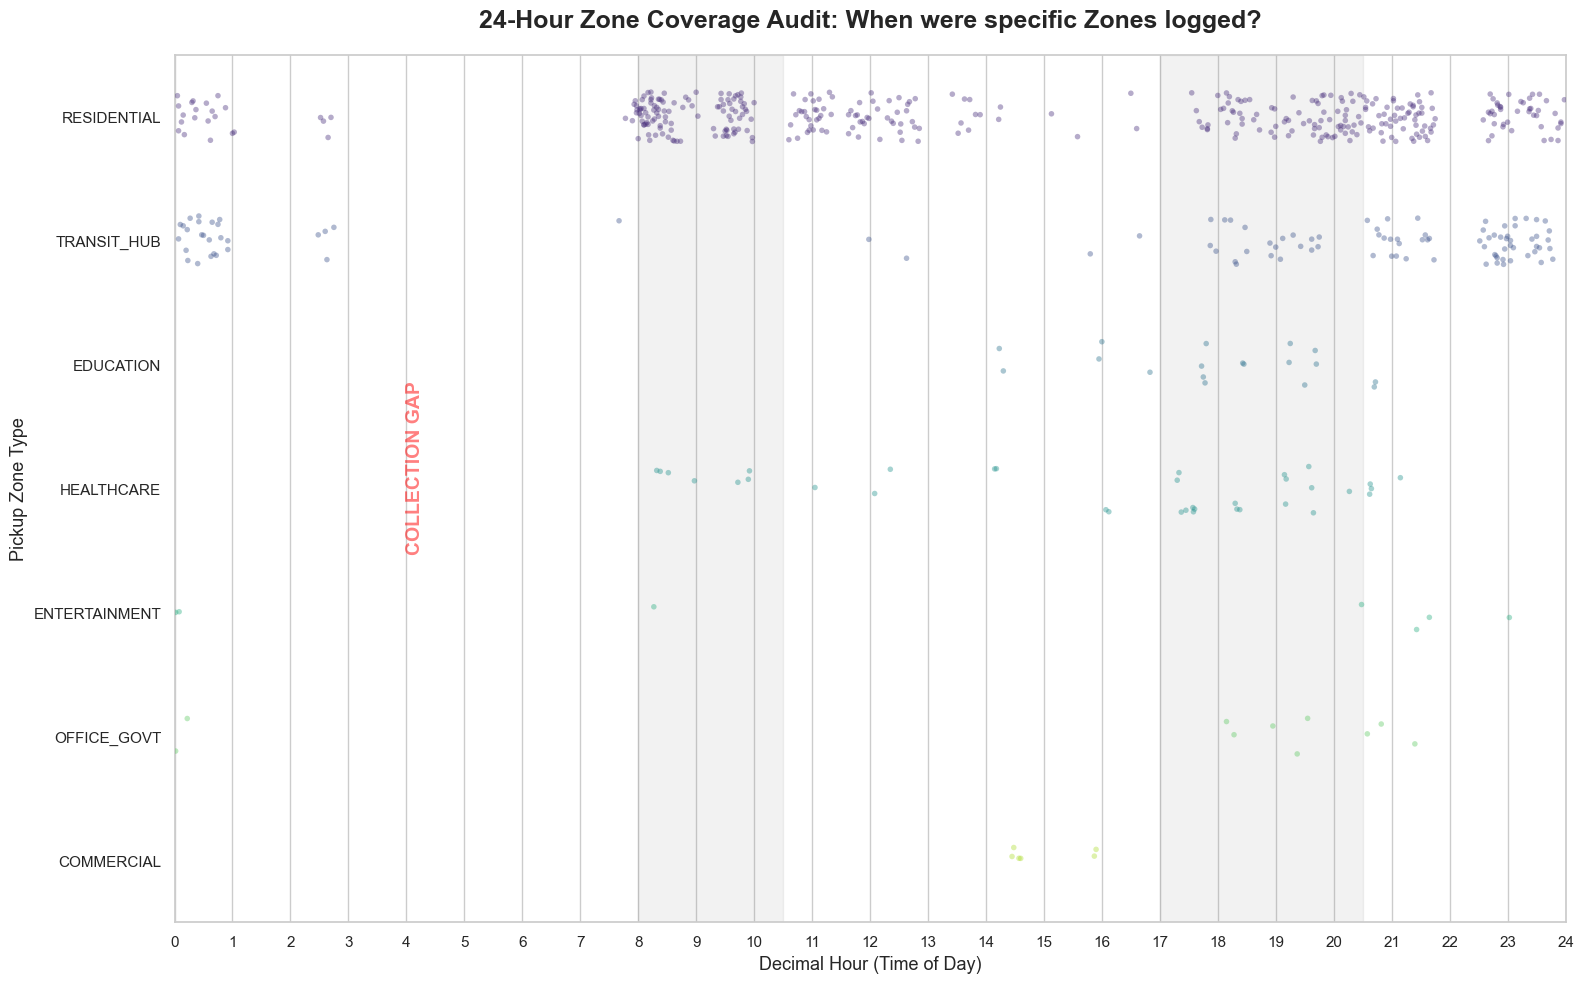

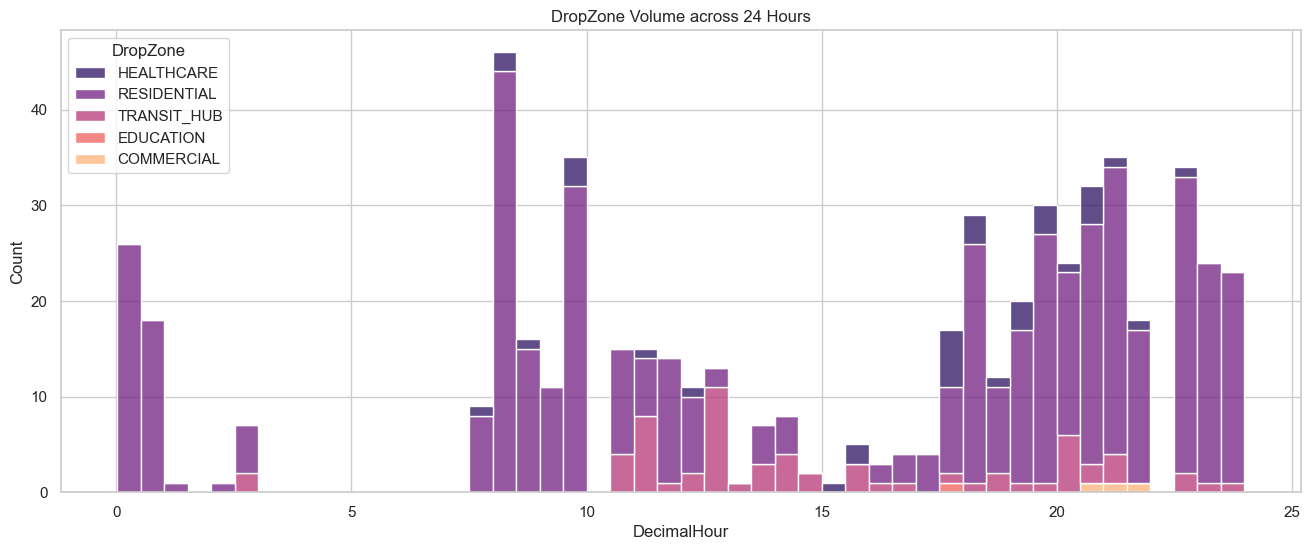

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

# 2. Setup the figure
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

# 3. Create a Categorical Scatter Plot (Stripplot)
# This shows every single data point as a thin dot to see the density
ax = sns.stripplot(
    data=df, 
    x='DecimalHour', 
    y='PickupZone', # Or 'PickupZone' depending on your exact CSV column name
    hue='PickupZone',
    palette='viridis',
    size=4, 
    alpha=0.4, 
    jitter=0.2,
    legend=False
)

# 4. Highlight Rush Hours to see if specific zones were ignored during peaks
plt.axvspan(8, 10.5, alpha=0.1, color='gray', label='Morning Rush')
plt.axvspan(17, 20.5, alpha=0.1, color='gray', label='Evening Rush')

# 5. Formatting
plt.xticks(np.arange(0, 25, 1))
plt.xlim(0, 24)

plt.title("24-Hour Zone Coverage Audit: When were specific Zones logged?", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Decimal Hour (Time of Day)", fontsize=13)
plt.ylabel("Pickup Zone Type", fontsize=13)

# Add a "Data Void" annotation to the most obvious gap
plt.text(4, len(df['PickupZone'].unique())/2, "COLLECTION GAP", 
         color='red', fontsize=14, fontweight='bold', rotation=90, alpha=0.5)

plt.tight_layout()
plt.show()

# --- OPTIONAL: DROPZONE SPREAD ---
# If you want to see if people are traveling TO specific zones at specific times
plt.figure(figsize=(16, 6))
sns.histplot(data=df, x='DecimalHour', hue='DropZone', multiple='stack', palette='magma', bins=48)
plt.title("DropZone Volume across 24 Hours")
plt.show()

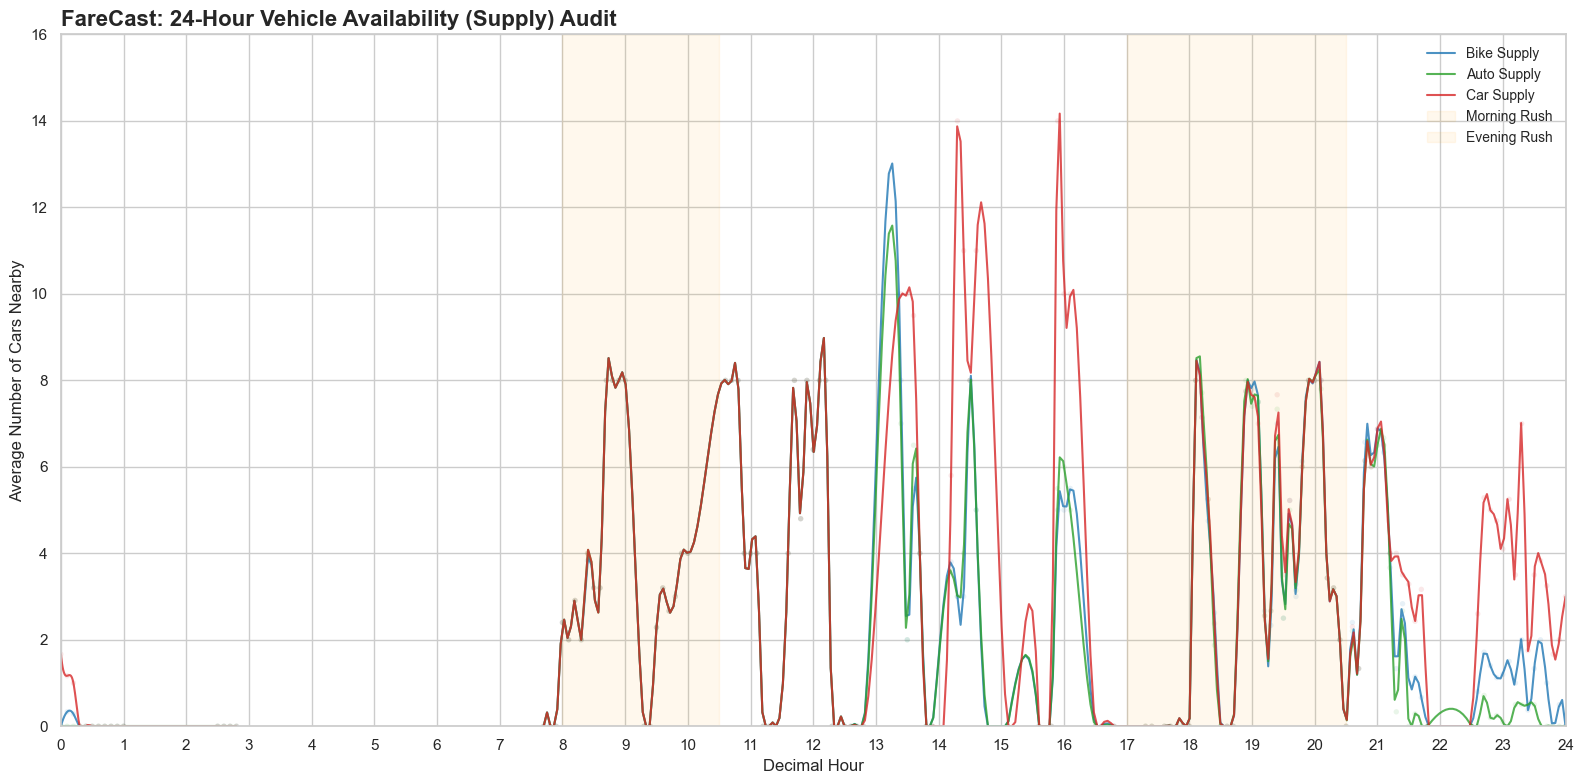

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

# 1. Load data
df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

# 2. Aggregation - Mean Supply per 0.1 hour slot
# Using your specific supply columns
agg_supply = df.groupby(df['DecimalHour'].round(1)).agg({
    'BikeSupply': 'mean',
    'AutoSupply': 'mean',
    'CarSupply': 'mean'
}).sort_index().reset_index()

def plot_supply_trends(ax, x, y, label, color):
    mask = ~np.isnan(y)
    x_c, y_c = x[mask], y[mask]
    
    if len(x_c) < 2: return

    # Scatter actual logs to show raw density
    ax.scatter(x_c, y_c, color=color, s=15, alpha=0.1, edgecolors='none')

    # Gap detection (1.5 hour threshold for supply voids)
    gaps = np.where(np.diff(x_c) > 1.5)[0] + 1
    x_segs = np.split(x_c, gaps)
    y_segs = np.split(y_c, gaps)
    
    first = True
    for xs, ys in zip(x_segs, y_segs):
        if len(xs) > 3:
            # Thin smooth spline for supply "waves"
            x_new = np.linspace(xs.min(), xs.max(), 300)
            spline = make_interp_spline(xs, ys, k=3)
            y_smooth = np.maximum(spline(x_new), 0)
            ax.plot(x_new, y_smooth, label=label if first else "", 
                    color=color, linewidth=1.5, alpha=0.8)
            first = False
        else:
            ax.plot(xs, ys, label=label if first else "", 
                    color=color, linewidth=1.5, alpha=0.6)
            first = False

# --- Visualization ---
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")
ax = plt.gca()

# Plotting each supply type
plot_supply_trends(ax, agg_supply['DecimalHour'].values, agg_supply['BikeSupply'].values, 'Bike Supply', '#1f77b4')
plot_supply_trends(ax, agg_supply['DecimalHour'].values, agg_supply['AutoSupply'].values, 'Auto Supply', '#2ca02c')
plot_supply_trends(ax, agg_supply['DecimalHour'].values, agg_supply['CarSupply'].values, 'Car Supply', '#d62728')

# Overlay Rush Hours
plt.axvspan(8, 10.5, alpha=0.07, color='orange', label='Morning Rush')
plt.axvspan(17, 20.5, alpha=0.07, color='orange', label='Evening Rush')

# Formatting
plt.xticks(np.arange(0, 25, 1))
plt.xlim(0, 24)
plt.ylim(0, df[['BikeSupply', 'AutoSupply', 'CarSupply']].max().max() + 2)

plt.title("FareCast: 24-Hour Vehicle Availability (Supply) Audit", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Decimal Hour", fontsize=12)
plt.ylabel("Average Number of Cars Nearby", fontsize=12)

# Legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

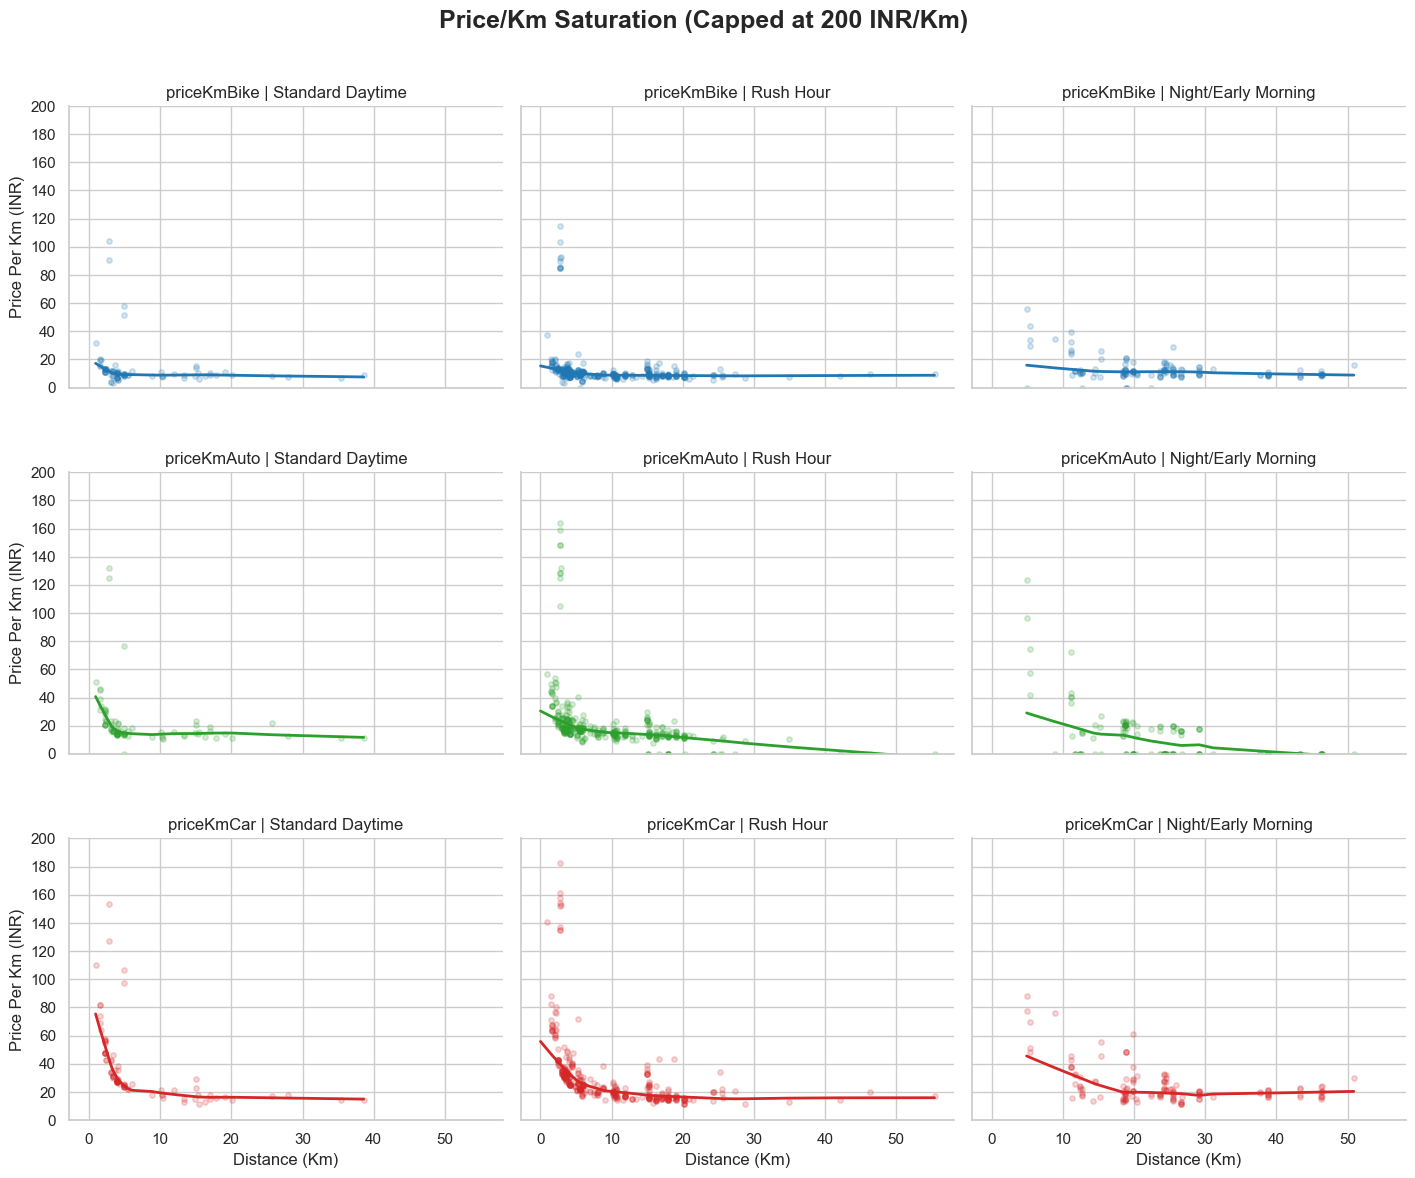

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

# 2. Categorize Time of Day
def get_time_cat(row):
    rush_col = 'RushHour' if 'RushHour' in df.columns else 'Rushhour'
    if row[rush_col] == 1:
        return 'Rush Hour'
    elif 6 <= row['DecimalHour'] < 22:
        return 'Standard Daytime'
    else:
        return 'Night/Early Morning'

df['TimeCategory'] = df.apply(get_time_cat, axis=1)

# 3. Melt the dataframe
df_long = pd.melt(df, 
                  id_vars=['DistanceKm', 'TimeCategory'], 
                  value_vars=['priceKmBike', 'priceKmAuto', 'priceKmCar'],
                  var_name='VehicleType', value_name='PricePerKm')

# 4. Create the FacetGrid with SHAREY=True
g = sns.FacetGrid(df_long, col="TimeCategory", row="VehicleType", 
                  hue="VehicleType", 
                  palette={'priceKmBike': '#1f77b4', 
                           'priceKmAuto': '#2ca02c', 
                           'priceKmCar': '#d62728'},
                  sharey=True, 
                  height=4, aspect=1.2)

# 5. Map the Lowess plot
# Any data points above 200 will simply be 'clipped' out of view
g.map(sns.regplot, "DistanceKm", "PricePerKm", 
      lowess=True, scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'linewidth': 2})

# 6. ENFORCE 20-UNIT INTERVALS (CAP AT 200)
y_ticks = np.arange(0, 201, 20) # 0, 20, 40 ... 200

g.set(yticks=y_ticks) 
g.set(ylim=(0, 200)) # This physically locks the view to your requested range

# 7. Aesthetics
g.set_axis_labels("Distance (Km)", "Price Per Km (INR)")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

plt.subplots_adjust(top=0.9, hspace=0.3)
g.fig.suptitle('Price/Km Saturation (Capped at 200 INR/Km)', fontsize=18, fontweight='bold')

plt.show()

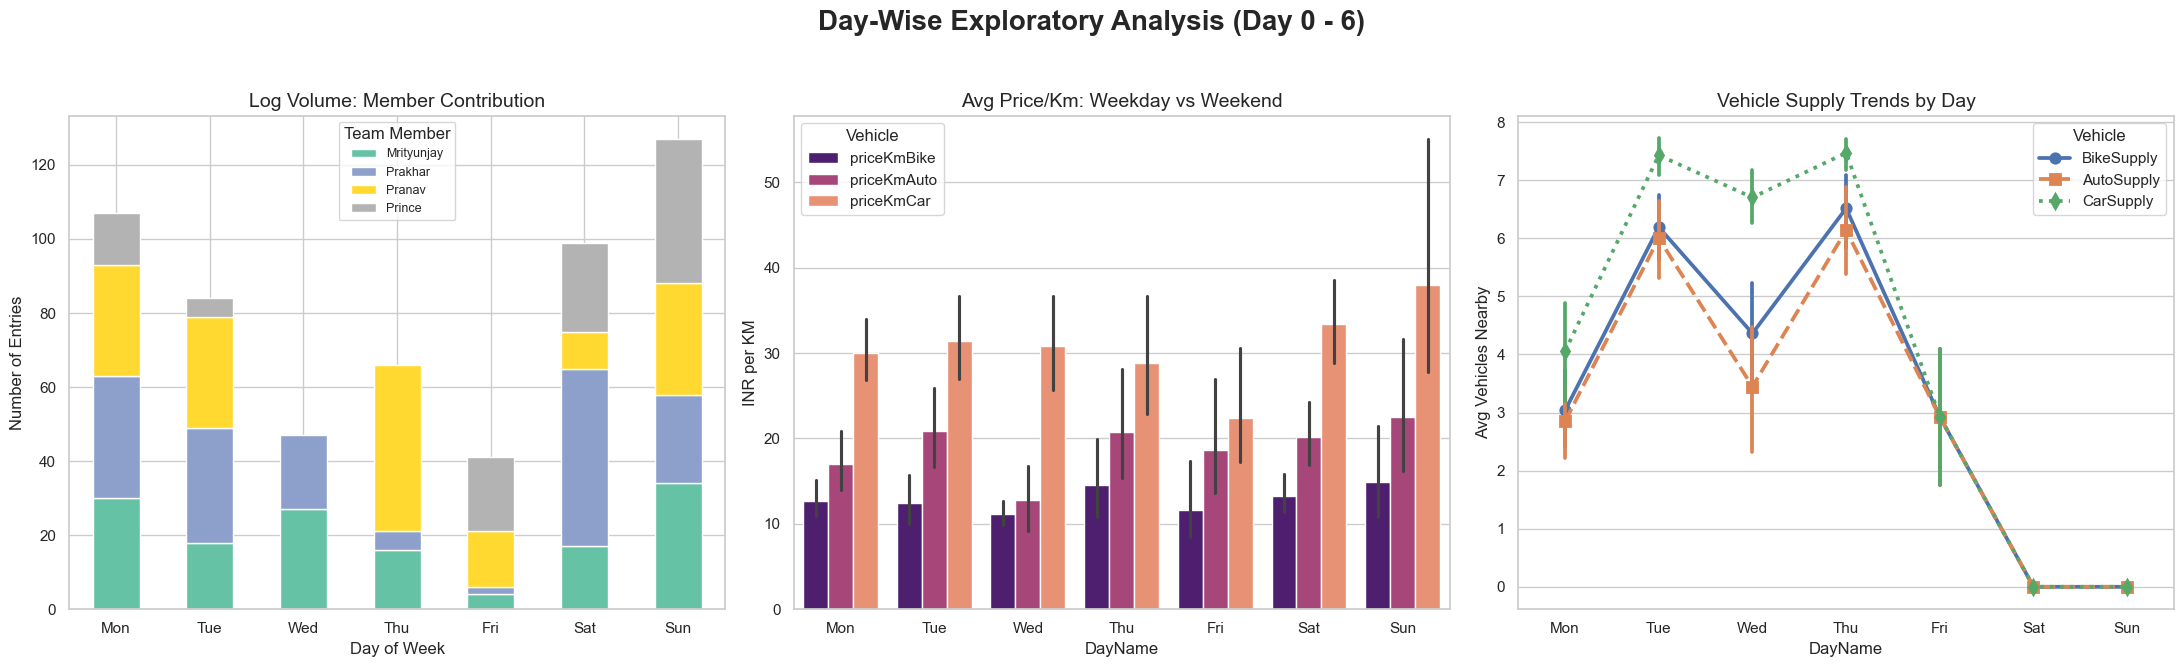

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

# 2. Map Day numbers to Names for readability
day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df['DayName'] = df['Day'].map(day_map)
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# 3. Create a Dashboard: Volume, Price, and Supply
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Day-Wise Exploratory Analysis (Day 0 - 6)', fontsize=20, fontweight='bold')

# --- PLOT 1: Data Volume (Stacked by Member) ---
# We create a cross-tabulation of Day vs Name and plot it as a stacked bar
volume_pivot = pd.crosstab(df['DayName'], df['Your Name']).reindex(day_order)
volume_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')

axes[0].set_title('Log Volume: Member Contribution', fontsize=14)
axes[0].set_ylabel('Number of Entries')
axes[0].set_xlabel('Day of Week')
axes[0].legend(title='Team Member', fontsize=9, loc='upper center')
axes[0].tick_params(axis='x', rotation=0) # Keep day names horizontal

# --- PLOT 2: Average Price/Km per Day ---
price_df = pd.melt(df, id_vars=['DayName'], 
                   value_vars=['priceKmBike', 'priceKmAuto', 'priceKmCar'],
                   var_name='Vehicle', value_name='Price')

sns.barplot(data=price_df, x='DayName', y='Price', hue='Vehicle', 
            order=day_order, palette='magma', ax=axes[1])
axes[1].set_title('Avg Price/Km: Weekday vs Weekend', fontsize=14)
axes[1].set_ylabel('INR per KM')

# --- PLOT 3: Supply Availability per Day ---
# Ensure these column names match your CSV (case-sensitive)
supply_df = pd.melt(df, id_vars=['DayName'], 
                    value_vars=['BikeSupply', 'AutoSupply', 'CarSupply'],
                    var_name='Vehicle', value_name='Supply')

sns.pointplot(data=supply_df, x='DayName', y='Supply', hue='Vehicle', 
              order=day_order, markers=['o', 's', 'd'], linestyles=['-', '--', ':'], ax=axes[2])
axes[2].set_title('Vehicle Supply Trends by Day', fontsize=14)
axes[2].set_ylabel('Avg Vehicles Nearby')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

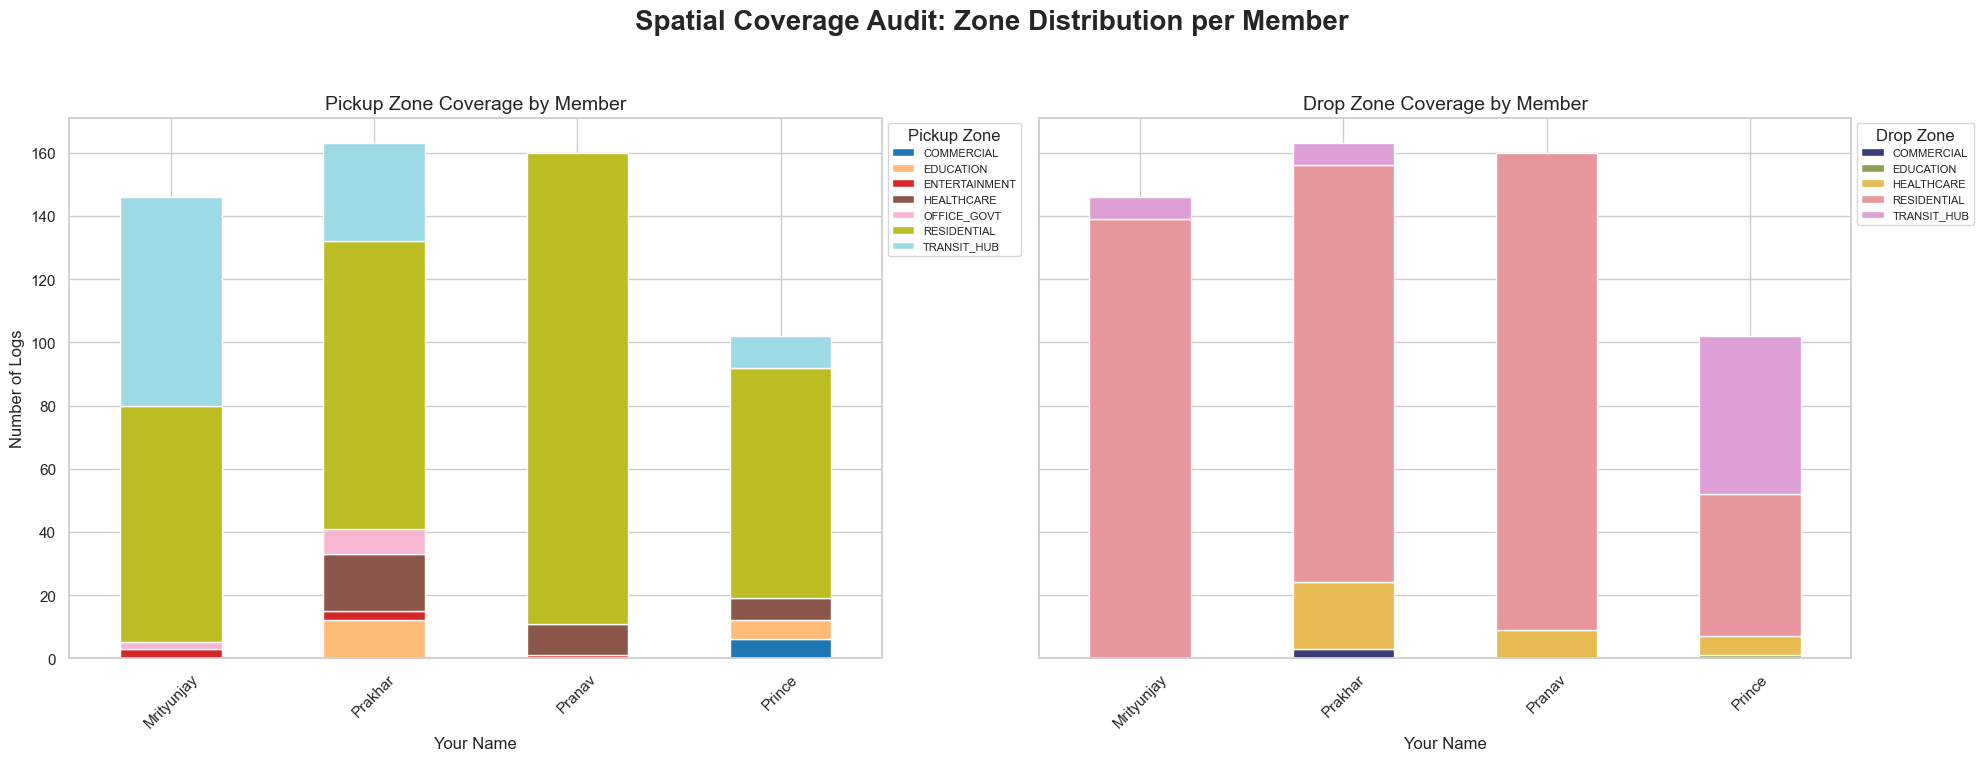

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

# 2. Setup a 1x2 Subplot (Pickup Zones vs Drop Zones)
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
fig.suptitle('Spatial Coverage Audit: Zone Distribution per Member', fontsize=20, fontweight='bold')

# --- PLOT 1: Pickup Zone Distribution ---
# Pivot data: Rows = Names, Columns = Pickup Zones, Values = Count
pickup_pivot = pd.crosstab(df['Your Name'], df['PickupZone'])
pickup_pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab20', edgecolor='white')

axes[0].set_title('Pickup Zone Coverage by Member', fontsize=14)
axes[0].set_ylabel('Number of Logs')
axes[0].legend(title='Pickup Zone', bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# --- PLOT 2: Drop Zone Distribution ---
# Pivot data: Rows = Names, Columns = Drop Zones, Values = Count
drop_pivot = pd.crosstab(df['Your Name'], df['DropZone'])
drop_pivot.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20b', edgecolor='white')

axes[1].set_title('Drop Zone Coverage by Member', fontsize=14)
axes[1].legend(title='Drop Zone', bbox_to_anchor=(1, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\princ\AppData\Local\Temp\ipykernel_7656\615586769.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='  Is a Surge/High-Demand alert visible?  ', y='priceKmCar', ax=axes[1,0], palette='coolwarm')


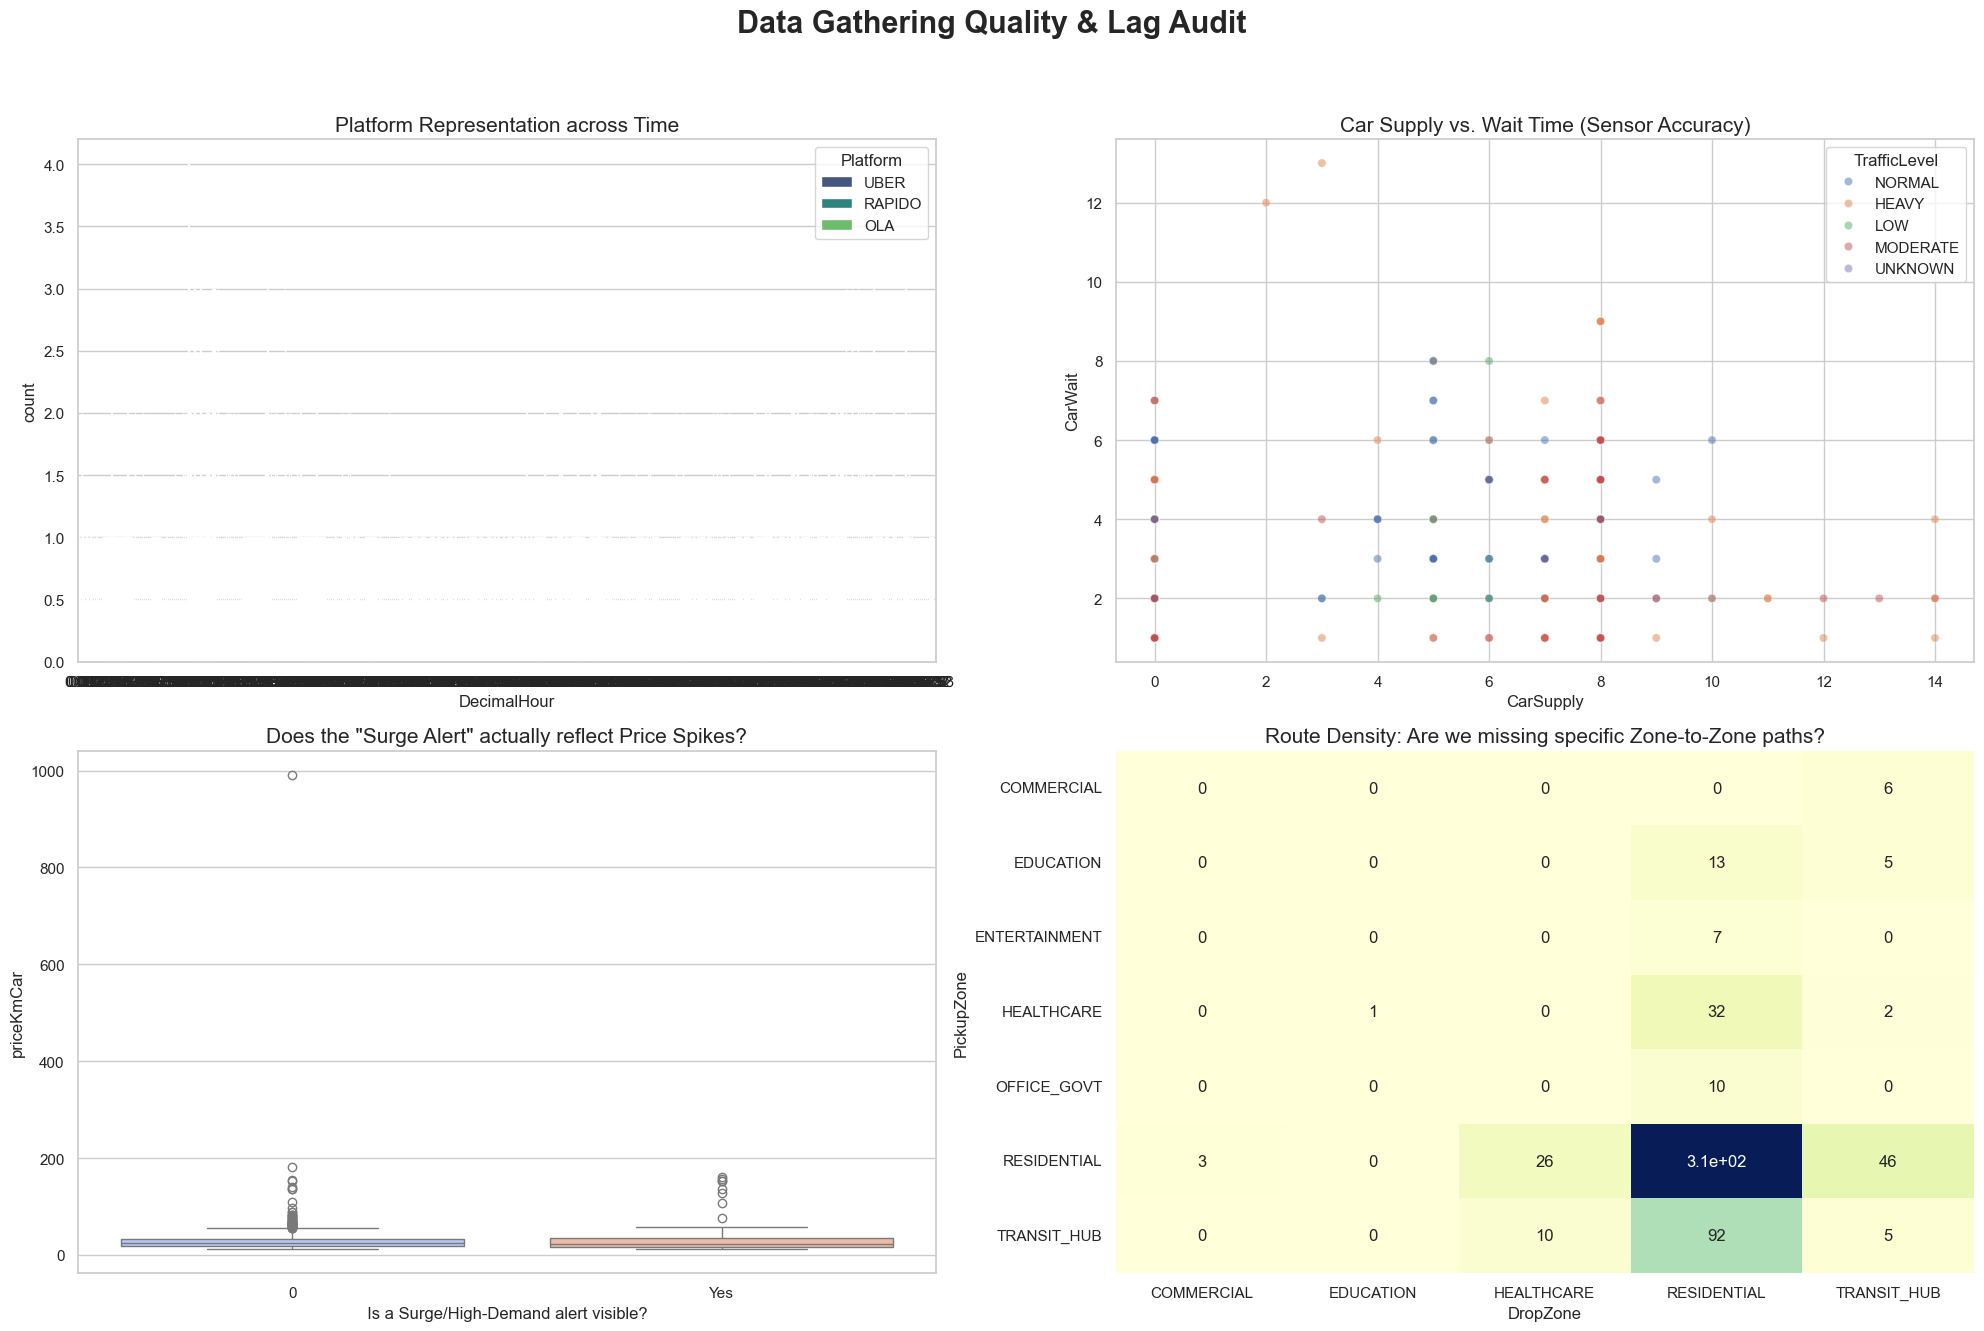

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Ride Apps Data Collection (Responses) - Form responses 2 (3).csv')

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Data Gathering Quality & Lag Audit', fontsize=22, fontweight='bold')

# --- 1. Platform Bias Audit ---
sns.countplot(data=df, x='DecimalHour', hue='Platform', ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Platform Representation across Time', fontsize=15)

# --- 2. Supply vs Wait (Efficiency Lag) ---
# Looking for 'Impossible' data: High Supply + High Wait
sns.scatterplot(data=df, x='CarSupply', y='CarWait', hue='TrafficLevel', ax=axes[0,1], alpha=0.5)
axes[0,1].set_title('Car Supply vs. Wait Time (Sensor Accuracy)', fontsize=15)

# --- 3. Surge Alert Validation ---
sns.boxplot(data=df, x='  Is a Surge/High-Demand alert visible?  ', y='priceKmCar', ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('Does the "Surge Alert" actually reflect Price Spikes?', fontsize=15)

# --- 4. Route Matrix (Spatial Gaps) ---
route_matrix = pd.crosstab(df['PickupZone'], df['DropZone'])
sns.heatmap(route_matrix, annot=True, cmap='YlGnBu', cbar=False, ax=axes[1,1])
axes[1,1].set_title('Route Density: Are we missing specific Zone-to-Zone paths?', fontsize=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


DATASET SHAPE
(571, 41)

COLUMN NAMES
Index(['Timestamp', 'Your Name', 'Pickup Coordinate', 'Drop Coordinate',
       'Fare for Bike', '[Waiting Time of Bike, No. of bikes available]',
       'Fare for Auto', '[Waiting Time of Auto, No. of Auto Available]',
       'Fare for Car', '[Waiting Time of Car, No. of cars available]',
       'Platform', '  Is a Surge/High-Demand alert visible?  ', 'Hour',
       'Minute', 'DecimalHour', 'Day', 'Weekend', 'Rushhour', 'DistanceKm',
       'Duration', 'TrafficLevel', 'SurgeValue', 'PickupTemperature',
       'PickupWindSpeed', 'PickupWeatherCode', 'PickupHumidity',
       'DropTemperature', 'DropWindSpeed', 'DropWeatherCode', 'DropHumidity',
       'PickupZone', 'DropZone', 'BikeWait', 'BikeSupply', 'AutoWait',
       'AutoSupply', 'CarWait', 'CarSupply', 'priceKmBike', 'priceKmAuto',
       'priceKmCar'],
      dtype='object')

CLEANED COLUMN NAMES
Index(['Timestamp', 'YourName', 'PickupCoordinate', 'DropCoordinate',
       'FareforBike', '[Wai

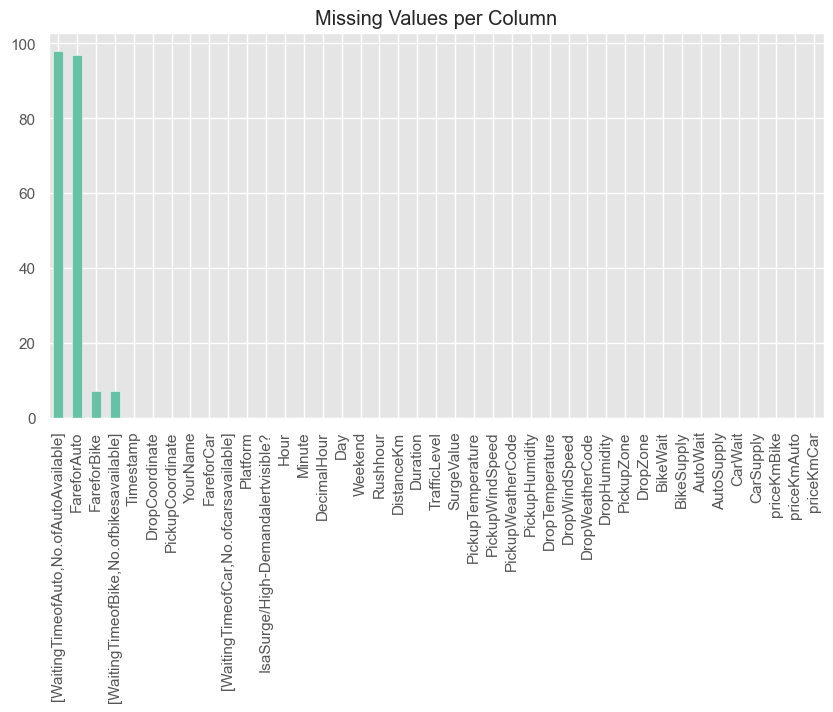


DUPLICATE ROWS: 105


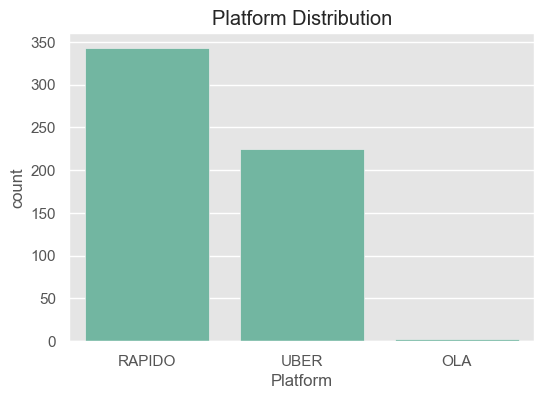


Platform counts
Platform
RAPIDO    343
UBER      225
OLA         3
Name: count, dtype: int64


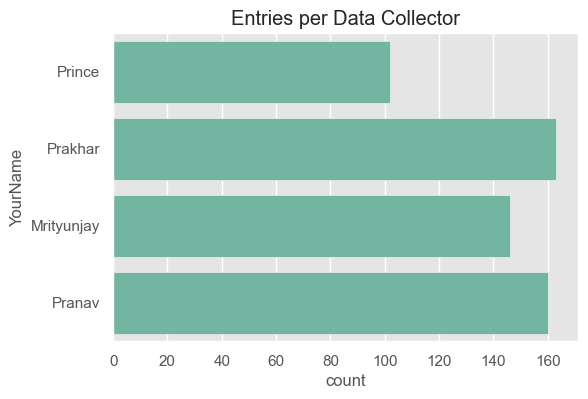

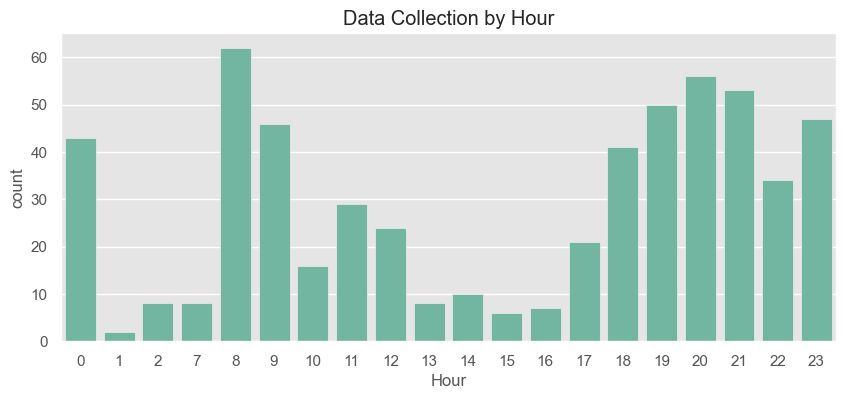

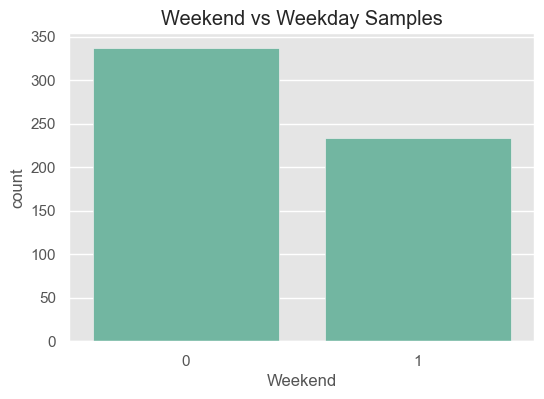

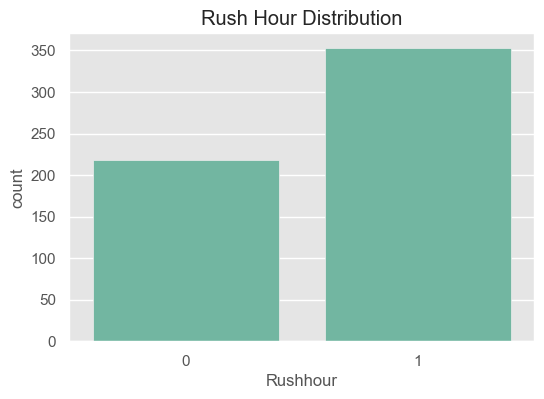

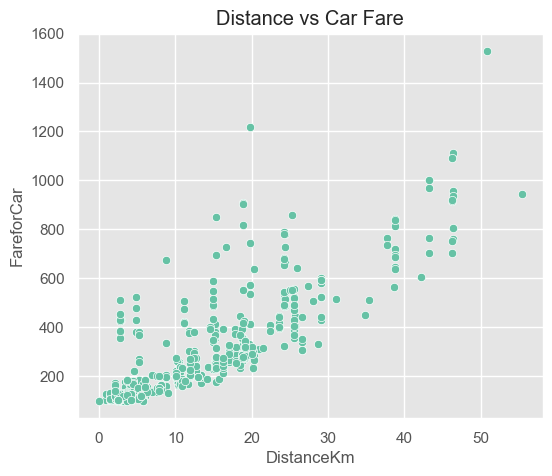

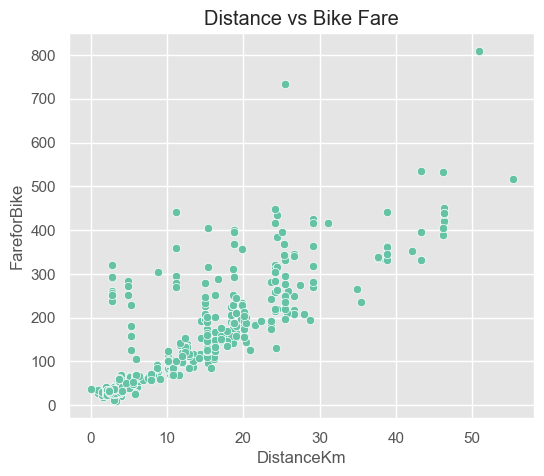

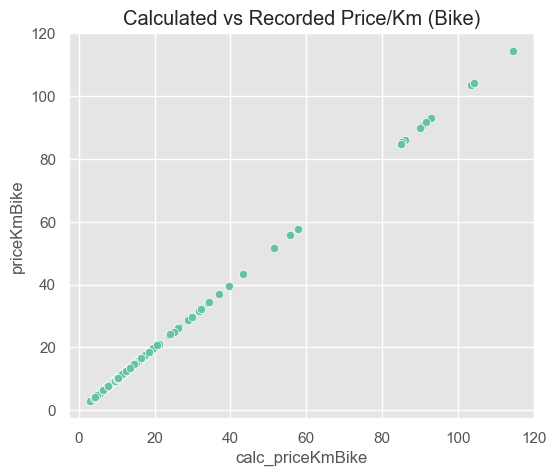

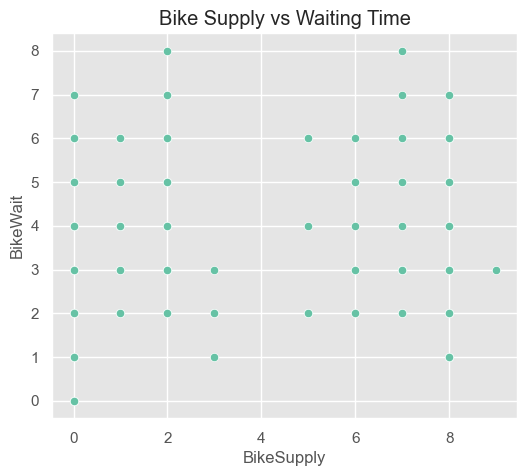

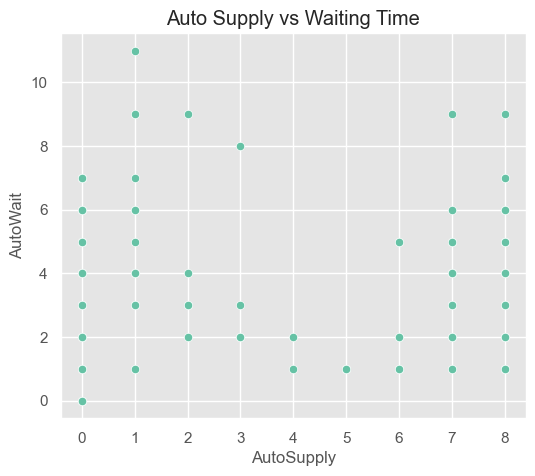

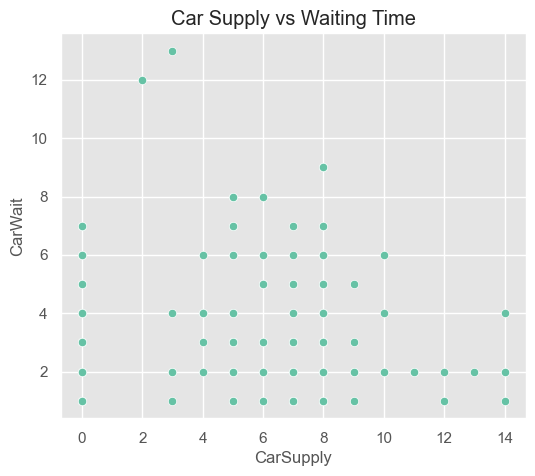

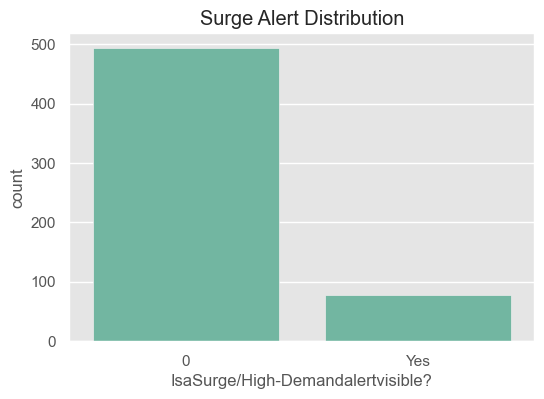

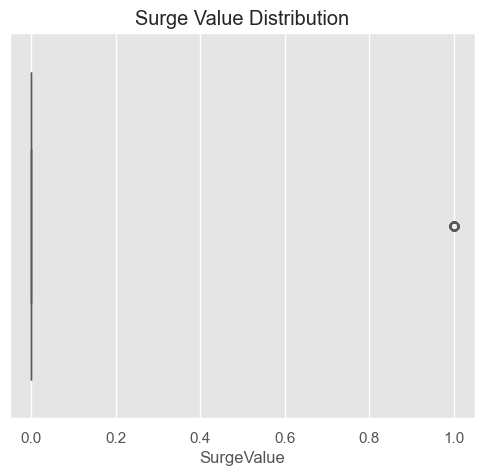

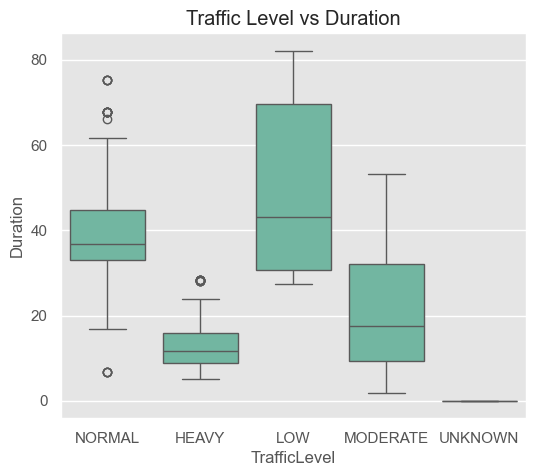

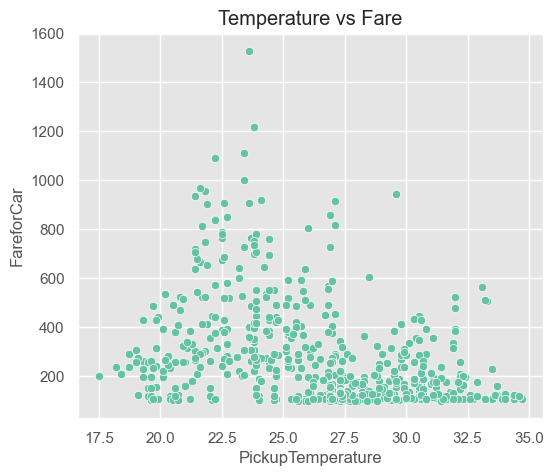

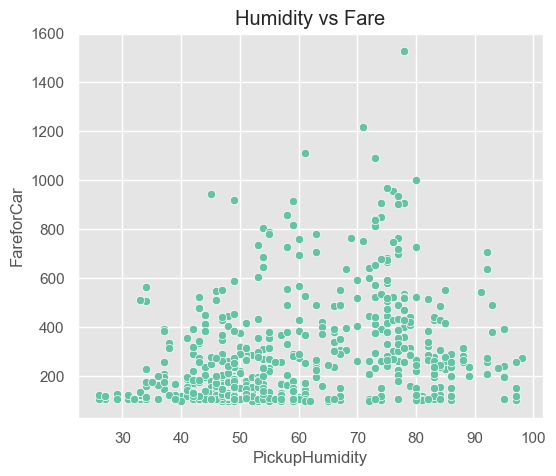

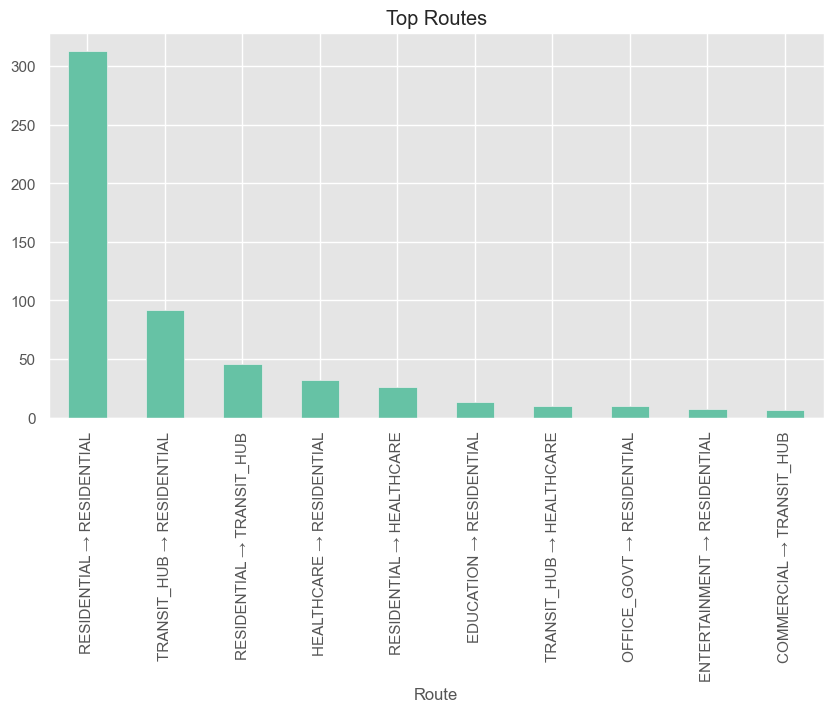

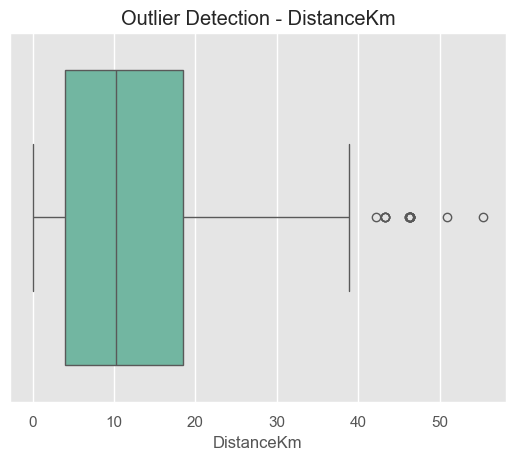

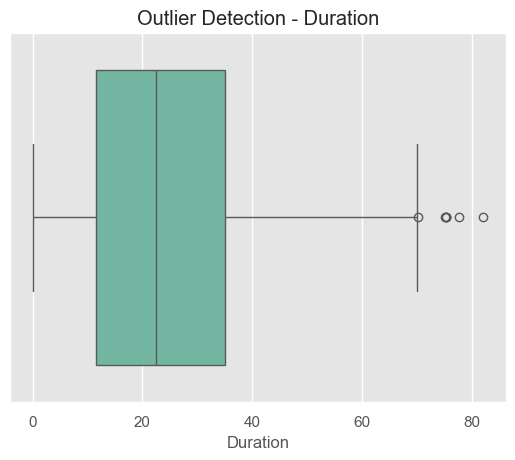

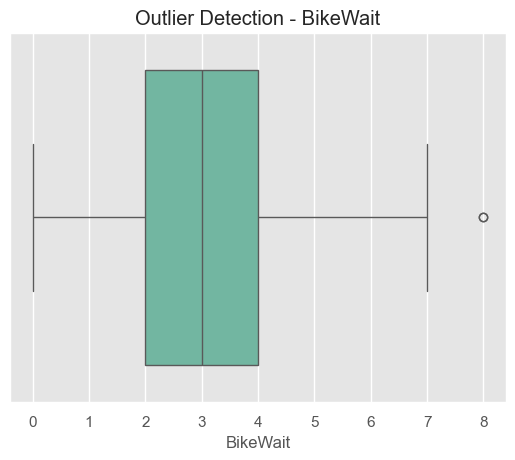

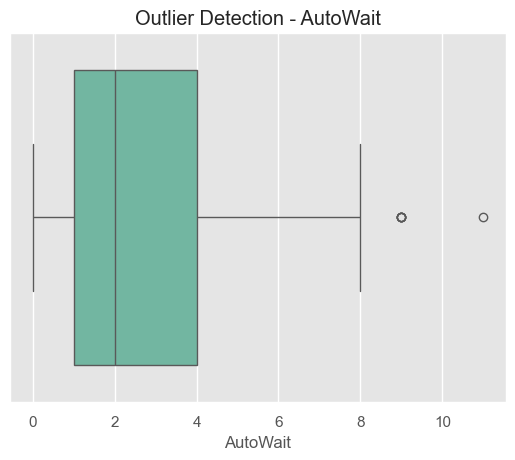

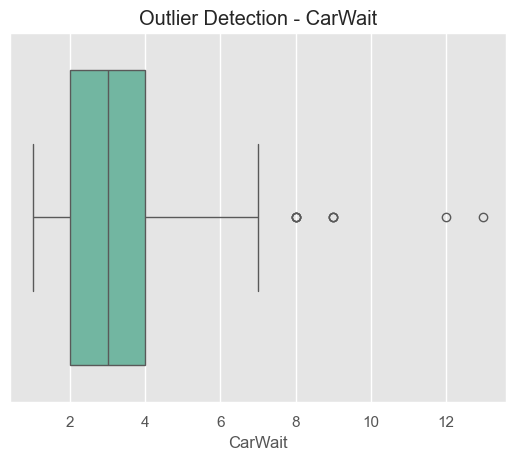

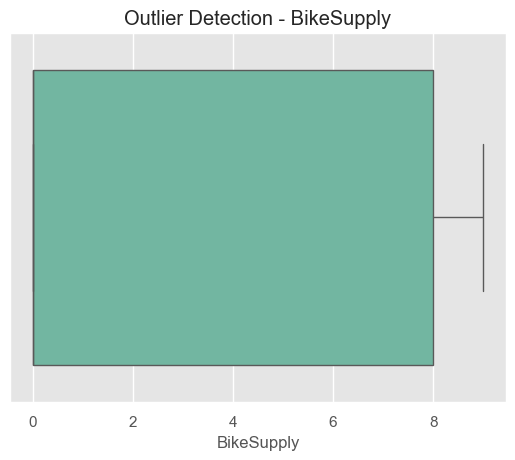

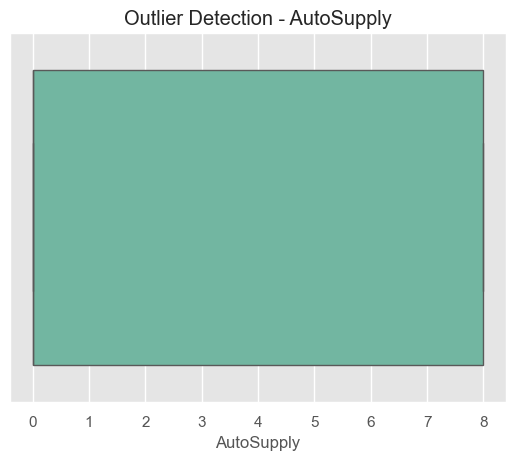

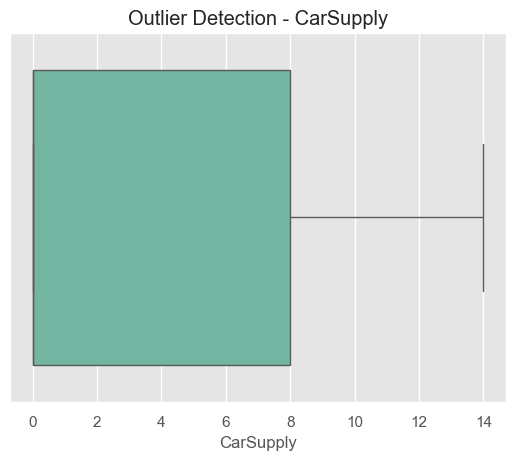

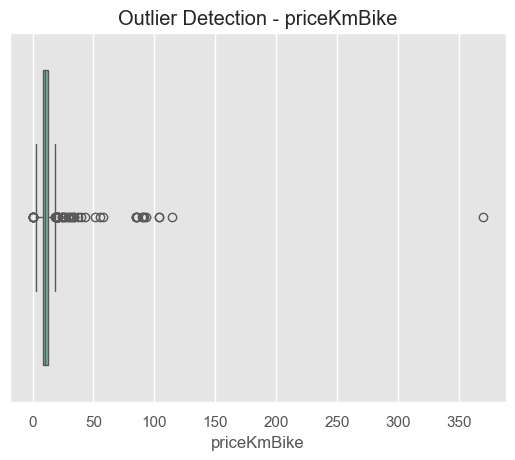

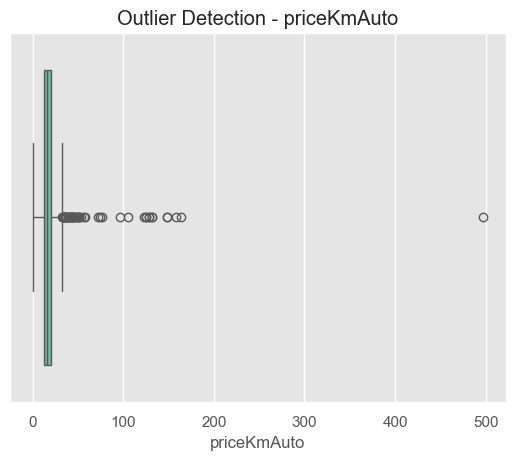

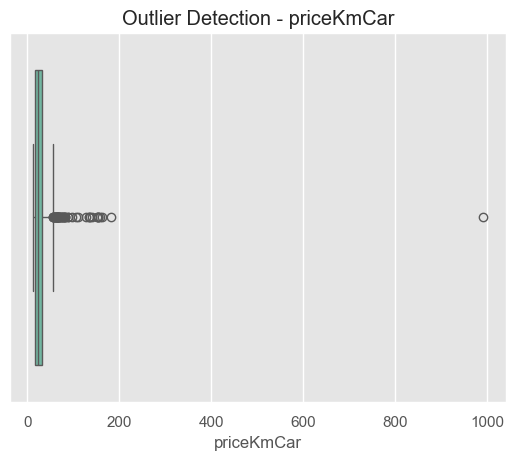

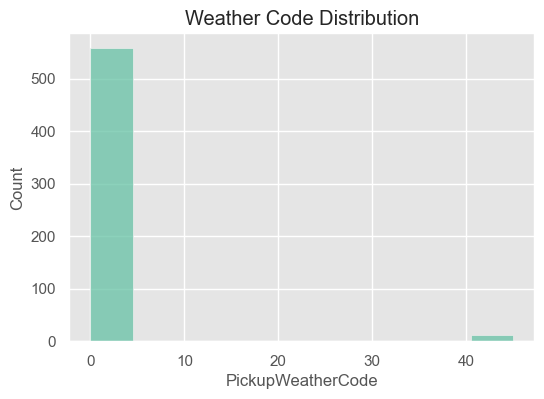

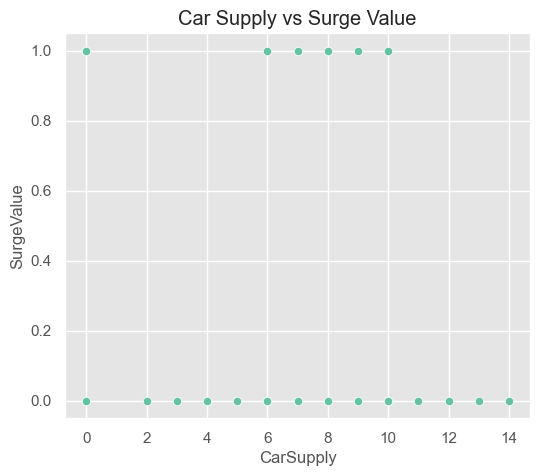

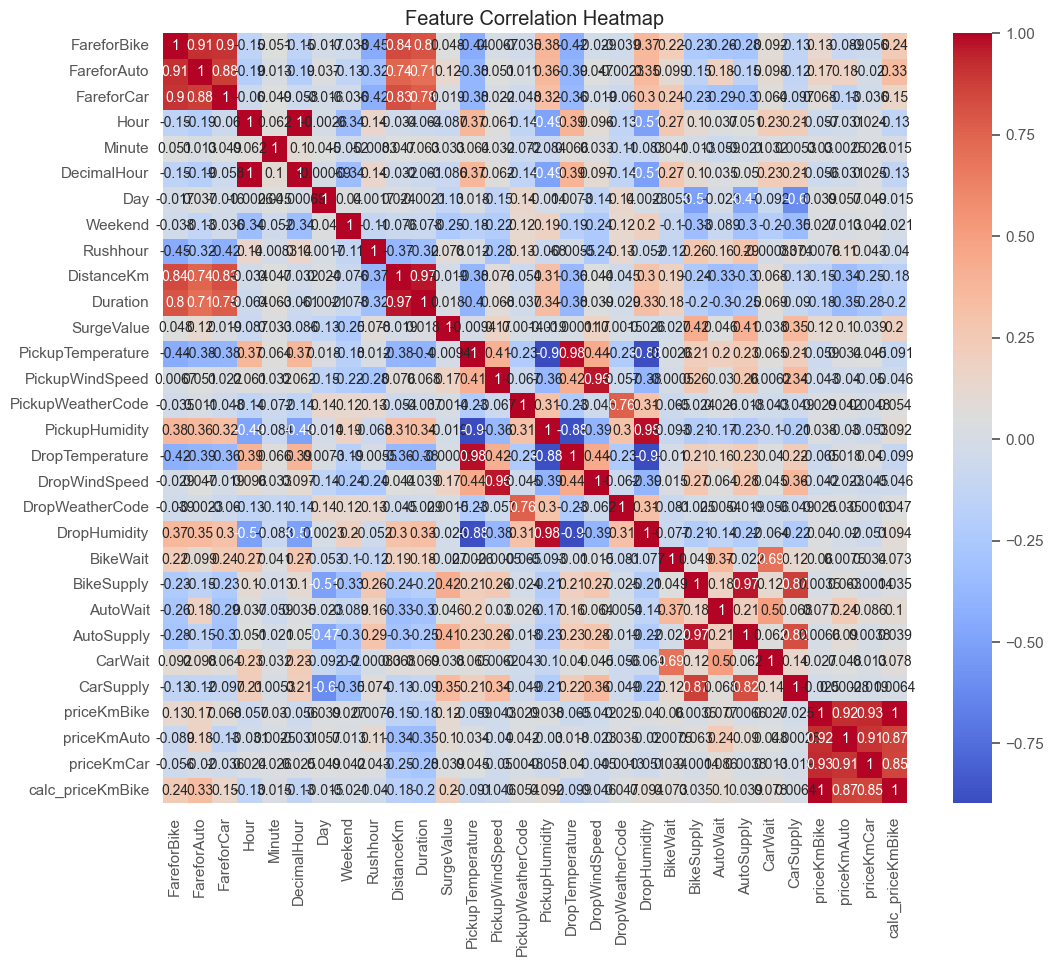


DATA QUALITY REPORT
Total rows: 571
Missing values: 216
Duplicate rows: 105

Platform balance:
Platform
RAPIDO    343
UBER      225
OLA         3
Name: count, dtype: int64

Surge samples:
IsaSurge/High-Demandalertvisible?
0      494
Yes     77
Name: count, dtype: int64

Average Distance: 12.544725043782838
Average Car Fare: 281.12252189141856

EDA COMPLETE


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

# -------------------------------------------------------
# 1 LOAD DATA
# -------------------------------------------------------

df = pd.read_csv("Ride Apps Data Collection (Responses) - Form responses 2 (3).csv")

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

# -------------------------------------------------------
# 2 CLEAN COLUMN NAMES
# -------------------------------------------------------

df.columns = df.columns.str.strip().str.replace(" ", "")

print("\nCLEANED COLUMN NAMES")
print(df.columns)

# -------------------------------------------------------
# 3 DATA TYPES
# -------------------------------------------------------

print("\nDATA TYPES")
print(df.dtypes)

# -------------------------------------------------------
# 4 MISSING VALUES
# -------------------------------------------------------

print("\nMISSING VALUES")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title("Missing Values per Column")
plt.show()

# -------------------------------------------------------
# 5 DUPLICATE ENTRIES
# -------------------------------------------------------

duplicates = df.duplicated(subset=[
    "PickupCoordinate",
    "DropCoordinate",
    "Platform",
    "Hour"
])

print("\nDUPLICATE ROWS:", duplicates.sum())

# -------------------------------------------------------
# 6 PLATFORM DISTRIBUTION
# -------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x=df["Platform"])
plt.title("Platform Distribution")
plt.show()

print("\nPlatform counts")
print(df["Platform"].value_counts())

# -------------------------------------------------------
# 7 DATA COLLECTOR BIAS
# -------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(y=df["YourName"])
plt.title("Entries per Data Collector")
plt.show()

# -------------------------------------------------------
# 8 TIME COVERAGE ANALYSIS
# -------------------------------------------------------

plt.figure(figsize=(10,4))
sns.countplot(x=df["Hour"])
plt.title("Data Collection by Hour")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=df["Weekend"])
plt.title("Weekend vs Weekday Samples")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=df["Rushhour"])
plt.title("Rush Hour Distribution")
plt.show()

# -------------------------------------------------------
# 9 DISTANCE VS FARE RELATIONSHIP
# -------------------------------------------------------

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["DistanceKm"], y=df["FareforCar"])
plt.title("Distance vs Car Fare")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["DistanceKm"], y=df["FareforBike"])
plt.title("Distance vs Bike Fare")
plt.show()

# -------------------------------------------------------
# 10 PRICE PER KM VALIDATION
# -------------------------------------------------------

df["calc_priceKmBike"] = df["FareforBike"] / df["DistanceKm"]

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["calc_priceKmBike"], y=df["priceKmBike"])
plt.title("Calculated vs Recorded Price/Km (Bike)")
plt.show()

# -------------------------------------------------------
# 11 WAITING TIME VS SUPPLY
# -------------------------------------------------------

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["BikeSupply"], y=df["BikeWait"])
plt.title("Bike Supply vs Waiting Time")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["AutoSupply"], y=df["AutoWait"])
plt.title("Auto Supply vs Waiting Time")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["CarSupply"], y=df["CarWait"])
plt.title("Car Supply vs Waiting Time")
plt.show()

# -------------------------------------------------------
# 12 SURGE ANALYSIS
# -------------------------------------------------------

plt.figure(figsize=(6,4))
sns.countplot(x=df["IsaSurge/High-Demandalertvisible?"])
plt.title("Surge Alert Distribution")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(x=df["SurgeValue"])
plt.title("Surge Value Distribution")
plt.show()

# -------------------------------------------------------
# 13 TRAFFIC VS DURATION
# -------------------------------------------------------

plt.figure(figsize=(6,5))
sns.boxplot(x=df["TrafficLevel"], y=df["Duration"])
plt.title("Traffic Level vs Duration")
plt.show()

# -------------------------------------------------------
# 14 WEATHER ANALYSIS
# -------------------------------------------------------

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["PickupTemperature"], y=df["FareforCar"])
plt.title("Temperature vs Fare")
plt.show()

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["PickupHumidity"], y=df["FareforCar"])
plt.title("Humidity vs Fare")
plt.show()

# -------------------------------------------------------
# 15 ROUTE ANALYSIS
# -------------------------------------------------------

df["Route"] = df["PickupZone"] + " → " + df["DropZone"]

top_routes = df["Route"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_routes.plot(kind="bar")
plt.title("Top Routes")
plt.show()

# -------------------------------------------------------
# 16 OUTLIER DETECTION
# -------------------------------------------------------

numeric_cols = [
    "DistanceKm","Duration",
    "BikeWait","AutoWait","CarWait",
    "BikeSupply","AutoSupply","CarSupply",
    "priceKmBike","priceKmAuto","priceKmCar"
]

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")
    plt.show()

# -------------------------------------------------------
# 17 WEATHER DIVERSITY
# -------------------------------------------------------

plt.figure(figsize=(6,4))
sns.histplot(df["PickupWeatherCode"], bins=10)
plt.title("Weather Code Distribution")
plt.show()

# -------------------------------------------------------
# 18 SUPPLY VS SURGE
# -------------------------------------------------------

plt.figure(figsize=(6,5))
sns.scatterplot(x=df["CarSupply"], y=df["SurgeValue"])
plt.title("Car Supply vs Surge Value")
plt.show()

# -------------------------------------------------------
# 19 CORRELATION MATRIX
# -------------------------------------------------------

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------------------------------
# 20 DATA QUALITY SUMMARY
# -------------------------------------------------------

print("\nDATA QUALITY REPORT")

print("Total rows:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", duplicates.sum())

print("\nPlatform balance:")
print(df["Platform"].value_counts())

print("\nSurge samples:")
print(df["IsaSurge/High-Demandalertvisible?"].value_counts())

print("\nAverage Distance:", df["DistanceKm"].mean())
print("Average Car Fare:", df["FareforCar"].mean())

print("\nEDA COMPLETE")